## 1. Imports

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## 2. Load Data

In [64]:
# Navigate to project workspace
os.chdir('/workspaces/DSE3101-Project')

# Verify correct directory location 
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder to obtain zip file that contains raw data
os.chdir('data/raw')
current_dir = os.getcwd()
print(f"Latest directory: {current_dir}")

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'requirements_fixed.txt', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']
Latest directory: /workspaces/DSE3101-Project/data/raw


In [65]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz', compression='gzip')

print(f"Dataframe shape: {hdb_df.shape}")

# Merge RPI (annual average)
rpi_df = pd.read_csv('HousingAndDevelopmentBoardHDBResalePriceIndex1Q2009100Quarterly.csv')
rpi_long = rpi_df.melt(id_vars='DataSeries', var_name='quarter_str', value_name='RPI')
rpi_long = rpi_long[rpi_long['DataSeries'] == 'HDB Resale Price Index'].copy()
rpi_long['sold_year'] = rpi_long['quarter_str'].str[:4].astype(int)
rpi_annual = rpi_long.groupby('sold_year')['RPI'].mean().reset_index()
hdb_df = hdb_df.merge(rpi_annual, on='sold_year', how='left')

hdb_df = hdb_df.dropna(subset=['RPI'])
print(f"After dropping missing RPI: {hdb_df.shape}")
hdb_df.info()

Dataframe shape: (259143, 37)
After dropping missing RPI: (256457, 38)
<class 'pandas.DataFrame'>
RangeIndex: 256457 entries, 0 to 256456
Data columns (total 38 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               256457 non-null  str    
 1   flat_type                          256457 non-null  str    
 2   block                              256457 non-null  str    
 3   street_name                        256457 non-null  str    
 4   storey_range                       256457 non-null  str    
 5   floor_area_sqm                     256457 non-null  float64
 6   flat_model                         256457 non-null  str    
 7   lease_commence_date                256457 non-null  int64  
 8   resale_price                       256457 non-null  float64
 9   remaining_lease                    256457 non-null  int64  
 10  sold_year                          256457 no

## 3. Exploratory Data Analysis

In [66]:
# Missing values
missing_values = hdb_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Drop duplicates
print(f"\nDuplicate rows: {hdb_df.duplicated().sum()}")
hdb_df = hdb_df.drop_duplicates()
duplicates_removed = hdb_df.duplicated().sum()
print(f"\nDuplicate rows remaining: {duplicates_removed}")

# Descriptive statistics
display(hdb_df[['floor_area_sqm', 'resale_price', 'remaining_lease', 'sold_year',
                'nearest_mrt_distance_m', 'num_amenities_within_1000m']].describe())

Missing values per column:
town                                 0
flat_type                            0
block                                0
street_name                          0
storey_range                         0
floor_area_sqm                       0
flat_model                           0
lease_commence_date                  0
resale_price                         0
remaining_lease                      0
sold_year                            0
address                              0
max_floor_lvl                        0
storey_mid                           0
storey_category                      0
region                               0
is_mature_estate                     0
latitude                             0
longitude                            0
matched_address                      0
status                               0
nearest_mrt_name                     0
nearest_mrt_distance_m               0
nearest_clinic_name                  0
nearest_clinic_distance_m            

,floor_area_sqm,resale_price,remaining_lease,sold_year,nearest_mrt_distance_m,num_amenities_within_1000m
count,256457.000000,2.564570e+05,256457.000000,256457.000000,256457.000000,256457.000000
mean,96.907870,5.124693e+05,74.222872,2020.401888,606.021257,22.941803
std,24.048654,1.829041e+05,13.737674,3.072595,368.976308,8.675089
min,31.000000,1.400000e+05,40.000000,2015.000000,34.000000,3.000000
25%,81.000000,3.780000e+05,63.000000,2018.000000,322.400000,17.000000
50%,93.000000,4.780000e+05,74.000000,2021.000000,536.600000,22.000000
75%,112.000000,6.150000e+05,87.000000,2023.000000,808.400000,28.000000
max,366.700000,1.658888e+06,98.000000,2025.000000,3574.500000,67.000000


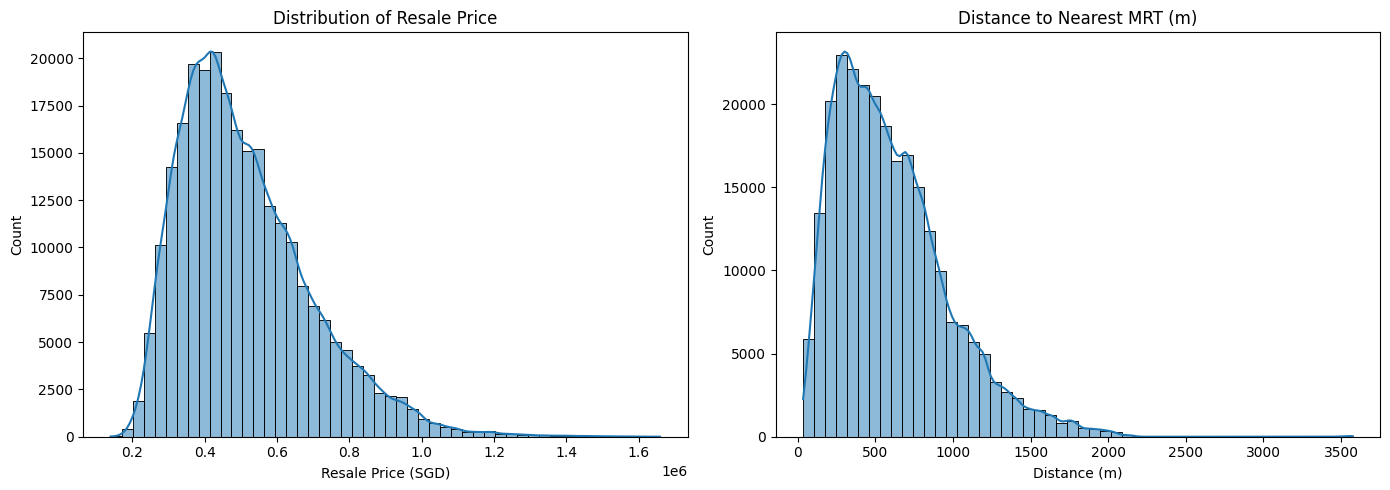

In [67]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(hdb_df['resale_price'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Distribution of Resale Price')
axes[0].set_xlabel('Resale Price (SGD)')

sns.histplot(hdb_df['nearest_mrt_distance_m'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Distance to Nearest MRT (m)')
axes[1].set_xlabel('Distance (m)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [68]:
df_model = hdb_df.copy()

# --- Flat age at sale ---
df_model['flat_age_at_sale'] = df_model['sold_year'] - df_model['lease_commence_date']

# --- Normalized target: remove floor area and time trend via RPI ---
df_model['log_price_norm'] = np.log(df_model['resale_price'] / (df_model['floor_area_sqm'] * df_model['RPI']))

# --- Drop columns: identifiers, leaky, redundant, or raw target ---
cols_to_drop = [
    # Identifiers / raw text
    'address', 'block', 'street_name', 'matched_address', 'status',
    'sold_year_month', 'max_floor_lvl', 'num_hawker_within_1000m',
    # Nearest facility names (not useful as features)
    'nearest_mrt_name', 'nearest_clinic_name', 'nearest_park_name',
    'nearest_community_club_name', 'nearest_hawker_name',
    # Raw coordinates (town + region encode location)
    'latitude', 'longitude',
    # Duplicate year column
    'year',
    # Target and RPI (used in target construction only)
    'resale_price', 'RPI',
]
df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])

# --- Encode categoricals ---
categorical_cols = df_model.select_dtypes(include=['object', 'str']).columns.tolist()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(f"Preprocessed shape: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()}")

Preprocessed shape: (256457, 24)
Columns: ['town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'sold_year', 'storey_mid', 'storey_category', 'region', 'is_mature_estate', 'nearest_mrt_distance_m', 'nearest_clinic_distance_m', 'nearest_park_distance_m', 'nearest_community_club_distance_m', 'nearest_hawker_distance_m', 'num_mrt_within_1000m', 'num_clinic_within_1000m', 'num_park_within_1000m', 'num_community_club_within_1000m', 'num_amenities_within_1000m', 'flat_age_at_sale', 'log_price_norm']


## 5. Train / Test Split

In [69]:
TREE_FEATURES = [c for c in df_model.columns if c != 'log_price_norm']

X_train, X_test, y_train, y_test = train_test_split(
    df_model[TREE_FEATURES],
    df_model['log_price_norm'],
    test_size=0.2,
    random_state=42
)

CURRENT_RPI = 203.6
y_test_actual = np.exp(y_test) * X_test['floor_area_sqm'] * CURRENT_RPI

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Features:     {len(TREE_FEATURES)}")

Training set: 205,165 rows
Test set:     51,292 rows
Features:     23


In [70]:
sample_weights = np.where(X_train['sold_year'] >= 2022, 2.0, 1.0)

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("Training complete.")

Training complete.


## 7. Evaluation

MAE:  $25,302.65
MAPE: 3.83%


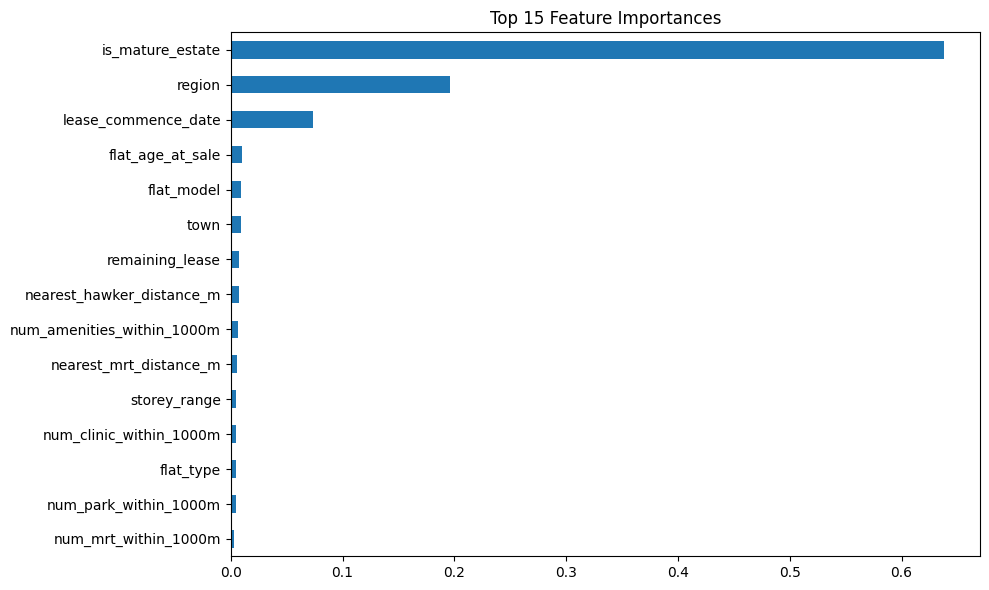

In [71]:
final_log_preds = xgb_model.predict(X_test)
final_dollar_preds = np.exp(final_log_preds) * X_test['floor_area_sqm'] * CURRENT_RPI

mae = mean_absolute_error(y_test_actual, final_dollar_preds)
mape = mean_absolute_percentage_error(y_test_actual, final_dollar_preds) * 100

print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")

# Feature importance (top 15)
feat_imp = pd.Series(xgb_model.feature_importances_, index=TREE_FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Prediction Function

In [72]:
# Per-town listing premium (transacted → asking price)
# Derived from validation against real listings — premium areas get higher multiplier
TOWN_PREMIUM = {
    'MARINE PARADE':     1.17,
    'QUEENSTOWN':        1.15,
    'CLEMENTI':          1.11,
    'BUKIT MERAH':       1.10,
    'BUKIT PANJANG':     1.10,
    'HOUGANG':           1.09,
    'BEDOK':             1.08,
    'KALLANG/WHAMPOA':   1.08,
    'JURONG EAST':       1.07,
    'BUKIT BATOK':       1.07,
    'CENTRAL AREA':      1.07,
    'TAMPINES':          1.07,
    'JURONG WEST':       1.06,
    'CHOA CHU KANG':     1.06,
    'SERANGOON':         1.06,
    'TOA PAYOH':         1.06,
    'PASIR RIS':         1.05,
    'ANG MO KIO':        1.05,
    'WOODLANDS':         1.05,
    'SENGKANG':          1.05,
    'YISHUN':            1.05,
    'BISHAN':            1.04,
    'PUNGGOL':           1.04,
    'BUKIT TIMAH':       1.03,
    'GEYLANG':           1.03,
    'SEMBAWANG':         1.02,
}
DEFAULT_PREMIUM = 1.07  # fallback for any unmapped town

# Per-flat-type adjustment on top of town premium
FLAT_TYPE_ADJUSTMENT = {
    '2 ROOM':           1.035,
    '3 ROOM':           1.014,
    'EXECUTIVE':        1.008,
    '4 ROOM':           0.998,
    '5 ROOM':           0.993,
    'MULTI-GENERATION': 1.000,
}

def predict_price(town, flat_type, floor_area, sold_year, remaining_lease=None):
    town_data = hdb_df[(hdb_df['town'] == town) &
                       (hdb_df['flat_type'] == flat_type) &
                       (hdb_df['sold_year'] >= 2022)]
    if town_data.empty:
        town_data = hdb_df[(hdb_df['town'] == town) & (hdb_df['flat_type'] == flat_type)]
    if town_data.empty:
        town_data = hdb_df[hdb_df['town'] == town]

    if remaining_lease is None:
        remaining_lease = int(town_data['remaining_lease'].median())

    flat_age = 99 - remaining_lease
    lease_commence_date = sold_year - flat_age

    input_dict = {
        'town':                           town,
        'flat_type':                      flat_type,
        'storey_range':                   town_data['storey_range'].mode()[0],
        'floor_area_sqm':                 floor_area,
        'flat_model':                     town_data['flat_model'].mode()[0],
        'lease_commence_date':            lease_commence_date,
        'remaining_lease':                remaining_lease,
        'sold_year':                      sold_year,
        'storey_mid':                     town_data['storey_mid'].median(),
        'storey_category':                town_data['storey_category'].mode()[0],
        'region':                         town_data['region'].mode()[0],
        'is_mature_estate':               int(town_data['is_mature_estate'].mode()[0]),
        'nearest_mrt_distance_m':         town_data['nearest_mrt_distance_m'].median(),
        'nearest_clinic_distance_m':      town_data['nearest_clinic_distance_m'].median(),
        'nearest_park_distance_m':        town_data['nearest_park_distance_m'].median(),
        'nearest_community_club_distance_m': town_data['nearest_community_club_distance_m'].median(),
        'nearest_hawker_distance_m':      town_data['nearest_hawker_distance_m'].median(),
        'num_mrt_within_1000m':           town_data['num_mrt_within_1000m'].median(),
        'num_clinic_within_1000m':        town_data['num_clinic_within_1000m'].median(),
        'num_park_within_1000m':          town_data['num_park_within_1000m'].median(),
        'num_community_club_within_1000m': town_data['num_community_club_within_1000m'].median(),
        'num_hawker_within_1000m':        town_data['num_hawker_within_1000m'].median(),
        'num_amenities_within_1000m':     town_data['num_amenities_within_1000m'].median(),
        'flat_age_at_sale':               flat_age,
    }

    for col in TREE_FEATURES:
        if col not in input_dict:
            input_dict[col] = X_train[col].median()

    input_df = pd.DataFrame([input_dict])[TREE_FEATURES]

    for col in categorical_cols:
        if col in input_df.columns:
            try:
                input_df[col] = encoders[col].transform(input_df[col].astype(str))
            except ValueError:
                input_df[col] = X_train[col].mode()[0]

    log_pred = xgb_model.predict(input_df)[0]
    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI
    listing_premium = TOWN_PREMIUM.get(town, DEFAULT_PREMIUM)
    flat_adj = FLAT_TYPE_ADJUSTMENT.get(flat_type, 1.0)
    return transacted * listing_premium * flat_adj

## 9. Example Predictions

In [73]:
# With remaining lease provided (e.g. 68 years left)
price = predict_price('QUEENSTOWN', '4 ROOM', 83, 2026, remaining_lease=68)
print(f"Estimated Listing Price: ${price:,.2f}")

# Without remaining lease (uses town median as fallback)
price2 = predict_price('QUEENSTOWN', '4 ROOM', 83, 2026)
print(f"Estimated Listing Price (no lease input): ${price2:,.2f}")

Estimated Listing Price: $774,710.56
Estimated Listing Price (no lease input): $1,018,152.19


In [74]:
## 11. Test Predictions Against Real Listings

listings_df = pd.read_csv('hdb_listings.csv')

# Clean floor area
listings_df['floorArea'] = listings_df['floorArea'].astype(str).str.replace(' sqm', '').str.strip()
listings_df['floorArea'] = pd.to_numeric(listings_df['floorArea'], errors='coerce')

# Map flat types to training format
flattype_map = {
    '2-Room': '2 ROOM', '3-Room': '3 ROOM', '4-Room': '4 ROOM',
    '5-Room': '5 ROOM', 'Executive': 'EXECUTIVE', 'Multi-Generation': 'MULTI-GENERATION',
}

# Map town names to training format
town_map = {
    'Ang Mo Kio': 'ANG MO KIO', 'Bedok': 'BEDOK', 'Bishan': 'BISHAN',
    'Bukit Batok': 'BUKIT BATOK', 'Bukit Merah': 'BUKIT MERAH',
    'Bukit Panjang': 'BUKIT PANJANG', 'Bukit Timah': 'BUKIT TIMAH',
    'Central': 'CENTRAL AREA', 'Choa Chu Kang': 'CHOA CHU KANG',
    'Clementi': 'CLEMENTI', 'Geylang': 'GEYLANG', 'Hougang': 'HOUGANG',
    'Jurong East': 'JURONG EAST', 'Jurong West': 'JURONG WEST',
    'Kallang/Whampoa': 'KALLANG/WHAMPOA', 'Marine Parade': 'MARINE PARADE',
    'Pasir Ris': 'PASIR RIS', 'Punggol': 'PUNGGOL', 'Queenstown': 'QUEENSTOWN',
    'Sembawang': 'SEMBAWANG', 'Sengkang': 'SENGKANG', 'Serangoon': 'SERANGOON',
    'Tampines': 'TAMPINES', 'Toa Payoh': 'TOA PAYOH', 'Woodlands': 'WOODLANDS',
    'Yishun': 'YISHUN',
}

listings_df['town_mapped'] = listings_df['town'].map(town_map)
listings_df['flattype_mapped'] = listings_df['flatType'].map(flattype_map)

valid_towns = set(hdb_df['town'].unique())
valid_flattypes = set(hdb_df['flat_type'].unique())

listings_clean = listings_df[
    listings_df['town_mapped'].isin(valid_towns) &
    listings_df['flattype_mapped'].isin(valid_flattypes) &
    listings_df['floorArea'].notna() &
    listings_df['price'].notna() &
    listings_df['maxRemainingLease'].notna()
].copy()

print(f"Valid listings for testing: {len(listings_clean)}")

# Run predictions
results = []
for _, row in listings_clean.iterrows():
    try:
        predicted = predict_price(
            town=row['town_mapped'],
            flat_type=row['flattype_mapped'],
            floor_area=float(row['floorArea']),
            sold_year=2026,
            remaining_lease=float(row['maxRemainingLease'])
        )
        actual = float(row['price'])
        error = predicted - actual
        pct_error = (error / actual) * 100
        results.append({
            'town': row['town_mapped'],
            'flat_type': row['flattype_mapped'],
            'floor_area': row['floorArea'],
            'remaining_lease': row['maxRemainingLease'],
            'actual_price': actual,
            'predicted_price': predicted,
            'error': error,
            'pct_error': pct_error,
            'abs_pct_error': abs(pct_error),
        })
    except Exception as e:
        pass

results_df = pd.DataFrame(results)

print(f"\n=== Prediction vs Listing Price ===")
print(f"Listings tested:       {len(results_df)}")
print(f"Mean error:            ${results_df['error'].mean():+,.0f}  (+ = overpredicting, - = underpredicting)")
print(f"Median abs error:      ${results_df['error'].abs().median():,.0f}")
print(f"MAE:                   ${results_df['error'].abs().mean():,.0f}")
print(f"MAPE:                  {results_df['abs_pct_error'].mean():.1f}%")

print(f"\n=== Error by Town (mean % error) ===")
town_errors = results_df.groupby('town')['pct_error'].mean().sort_values()
print(town_errors.round(1).to_string())

print(f"\n=== Error by Flat Type (mean % error) ===")
type_errors = results_df.groupby('flat_type')['pct_error'].mean().sort_values()
print(type_errors.round(1).to_string())

Valid listings for testing: 2095

=== Prediction vs Listing Price ===
Listings tested:       2095
Mean error:            $-9,772  (+ = overpredicting, - = underpredicting)
Median abs error:      $36,676
MAE:                   $53,719
MAPE:                  7.1%

=== Error by Town (mean % error) ===
town
SERANGOON         -2.2
CENTRAL AREA      -2.1
BUKIT MERAH       -1.2
PASIR RIS         -1.2
SEMBAWANG         -1.2
BISHAN            -1.0
PUNGGOL           -0.9
WOODLANDS         -0.9
MARINE PARADE     -0.8
ANG MO KIO        -0.8
SENGKANG          -0.8
KALLANG/WHAMPOA   -0.6
TOA PAYOH         -0.6
YISHUN            -0.6
CHOA CHU KANG     -0.5
JURONG WEST       -0.3
JURONG EAST       -0.2
HOUGANG           -0.2
QUEENSTOWN        -0.1
BEDOK             -0.1
BUKIT BATOK        0.1
TAMPINES           0.3
GEYLANG            0.4
BUKIT TIMAH        0.5
BUKIT PANJANG      0.5
CLEMENTI           2.0

=== Error by Flat Type (mean % error) ===
flat_type
2 ROOM             -1.2
MULTI-GENERATION   -

In [ ]:
import joblib

# Run this at the end of your training notebook
export_artifacts = {
    'xgb_model': xgb_model,
    'hdb_df': hdb_df,
    'X_train': X_train,
    'encoders': encoders,
    'TREE_FEATURES': TREE_FEATURES,
    'categorical_cols': categorical_cols,
    'CURRENT_RPI': CURRENT_RPI
}

# Added compress=7 to shrink the file size below GitHub's 100MB limit
# The compression level ranges from 0 to 9 
joblib.dump(export_artifacts, 'hdb_model_artifacts.pkl', compress=9)